## Tuning CatBoost
- Boosting - iterations (num_trees, n_estimators), learning_rate (eta), early_stopping_rounds

- Tree based - depth (max_depth), grow_policy, min_child_samples (min_data_in_leaf), max_leaves (num_leaves)

- Sampling - subsample, sampling_frequency, rsm (colsample_bylevel), random_strength, bagging_temperature

- Regularization - l2_leaf_reg (reg_lambda), model_shrink_rate

- Constraints - monotone_constraints, feature_weights

In [1]:
# Initialisation
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
# Custom import
from get_dataset_pandas import get_pandas_df
from pipes_and_transformers_pandas import get_pipeline_pandas

# Gets Polars dataframe.
raw = get_pandas_df()

y = raw["price"]
X_train, X_test, y_train, y_test = train_test_split(raw, y, test_size=0.2, random_state=42)

In [2]:
from catboost import CatBoostRegressor

help(CatBoostRegressor)

Help on class CatBoostRegressor in module catboost.core:

class CatBoostRegressor(CatBoost)
 |  CatBoostRegressor(iterations=None, learning_rate=None, depth=None, l2_leaf_reg=None, model_size_reg=None, rsm=None, loss_function='RMSE', border_count=None, feature_border_type=None, per_float_feature_quantization=None, input_borders=None, output_borders=None, fold_permutation_block=None, od_pval=None, od_wait=None, od_type=None, nan_mode=None, counter_calc_method=None, leaf_estimation_iterations=None, leaf_estimation_method=None, thread_count=None, random_seed=None, use_best_model=None, best_model_min_trees=None, verbose=None, silent=None, logging_level=None, metric_period=None, ctr_leaf_count_limit=None, store_all_simple_ctr=None, max_ctr_complexity=None, has_time=None, allow_const_label=None, target_border=None, one_hot_max_size=None, random_strength=None, random_score_type=None, name=None, ignored_features=None, train_dir=None, custom_metric=None, eval_metric=None, bagging_temperature=No

In [3]:
cr2 = CatBoostRegressor(iterations=3000, learning_rate=0.1, early_stopping_rounds=10)

X_train, X_test, y_train, y_test = train_test_split(raw.drop(columns=['price']), 
                                                    y, test_size=0.2, random_state=42)

cr2.fit(X_train, y_train, cat_features=['zipcode'], verbose=100, eval_set=(X_test, y_test))

0:	learn: 339551.2652083	test: 365581.8956335	best: 365581.8956335 (0)	total: 188ms	remaining: 9m 22s
100:	learn: 105408.7079747	test: 126346.4018871	best: 126346.4018871 (100)	total: 4.67s	remaining: 2m 14s
200:	learn: 89677.3002786	test: 119812.4075780	best: 119812.4075780 (200)	total: 9.14s	remaining: 2m 7s
300:	learn: 81329.9291002	test: 116929.7601480	best: 116843.4884029 (298)	total: 13.7s	remaining: 2m 2s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 116208.1266
bestIteration = 357

Shrink model to first 358 iterations.


CatBoostRegressor(early_stopping_rounds=10, iterations=3000, learning_rate=0.1, loss_function='RMSE')

In [4]:
# plot a validation curve tracking mse as the max_depth of the decision tree increases
"""
Takes quite awhile to run.
"""

"""
from sklearn.model_selection import validation_curve

param_range = range(1, 10)
train_scores, test_scores = validation_curve(
    cr2, X_train, y_train, param_name="max_depth", 
    param_range=param_range,
    scoring="neg_mean_squared_error", n_jobs=1)
"""
    
"""    
Unable to get the following arguments to work.
    fit_params=dict(early_stopping_rounds=10, 
                    eval_set=(X_test, y_test))
"""

# Codex AI recommended fix
from sklearn.model_selection import validation_curve

# IDLE compatible
param_range = np.array(list(range(1, 10)), dtype=float)

#param_range = list(range(1, 10))
train_scores, test_scores = validation_curve(
    cr2,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=range(1, 10),
    scoring="neg_mean_squared_error",
    n_jobs=1,
    params={
        # only if cr2.fit supports these
        "early_stopping_rounds": 10,
        "eval_set": [(X_test, y_test)],
    },
)

0:	learn: 342021.6361785	test: 377804.8700947	best: 377804.8700947 (0)	total: 3.46ms	remaining: 10.4s
1:	learn: 332228.0272651	test: 367457.6657394	best: 367457.6657394 (1)	total: 6.01ms	remaining: 9.01s
2:	learn: 323431.4757030	test: 358127.1657088	best: 358127.1657088 (2)	total: 7.32ms	remaining: 7.31s
3:	learn: 315361.9138497	test: 350184.8862894	best: 350184.8862894 (3)	total: 8.59ms	remaining: 6.43s
4:	learn: 308756.6195265	test: 343042.6967948	best: 343042.6967948 (4)	total: 9.83ms	remaining: 5.89s
5:	learn: 302023.2764189	test: 336364.5794504	best: 336364.5794504 (5)	total: 11.1ms	remaining: 5.56s
6:	learn: 296484.0220188	test: 331310.2851736	best: 331310.2851736 (6)	total: 12.5ms	remaining: 5.34s
7:	learn: 290617.7311175	test: 324913.4445324	best: 324913.4445324 (7)	total: 14.9ms	remaining: 5.58s
8:	learn: 285423.7208965	test: 319883.9792734	best: 319883.9792734 (8)	total: 16.5ms	remaining: 5.49s
9:	learn: 280936.9377391	test: 315418.4690016	best: 315418.4690016 (9)	total: 19.3

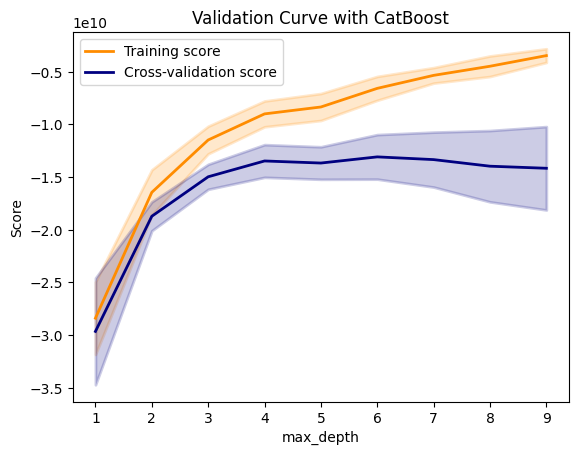

In [5]:
# make a validation curve from train_scores and test_scores
"""
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
"""

# IDLE Compatible
train_scores_mean = np.asarray(np.mean(train_scores, axis=1), dtype=float)
train_scores_std = np.asarray(np.std(train_scores, axis=1), dtype=float)
test_scores_mean = np.asarray(np.mean(test_scores, axis=1), dtype=float)
test_scores_std = np.asarray(np.std(test_scores, axis=1), dtype=float)

plt.title("Validation Curve with CatBoost")
plt.xlabel("max_depth")
plt.ylabel("Score")
#plt.ylim(-1, 0)
lw = 2
plt.plot(param_range, train_scores_mean, label="Training score",
             color="darkorange", lw=lw)
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange", lw=lw)
plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                color="navy", lw=lw)

plt.fill_between(param_range, test_scores_mean - test_scores_std,   
                    test_scores_mean + test_scores_std, alpha=0.2,
                    color="navy", lw=lw)
plt.legend(loc="best")
plt.show()

In [6]:
# set max_depth to 4
cr2_4 = CatBoostRegressor(iterations=3000, learning_rate=0.1,
                                max_depth=4)

X_train, X_test, y_train, y_test = train_test_split(raw.drop(columns=['price']), y, 
                                                    test_size=0.2, random_state=42)

cr2_4.fit(X_train, y_train, cat_features=['zipcode'], verbose=100,
        early_stopping_rounds=10, eval_set=(X_test, y_test))
cr2_4.score(X_test, y_test)

0:	learn: 341570.5994602	test: 368041.6290994	best: 368041.6290994 (0)	total: 27.9ms	remaining: 1m 23s
100:	learn: 117424.7526864	test: 143390.6149138	best: 143390.6149138 (100)	total: 2.94s	remaining: 1m 24s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 137942.8426
bestIteration = 171

Shrink model to first 172 iterations.


np.float64(0.8741325463996936)